**Imports & Image Loading**

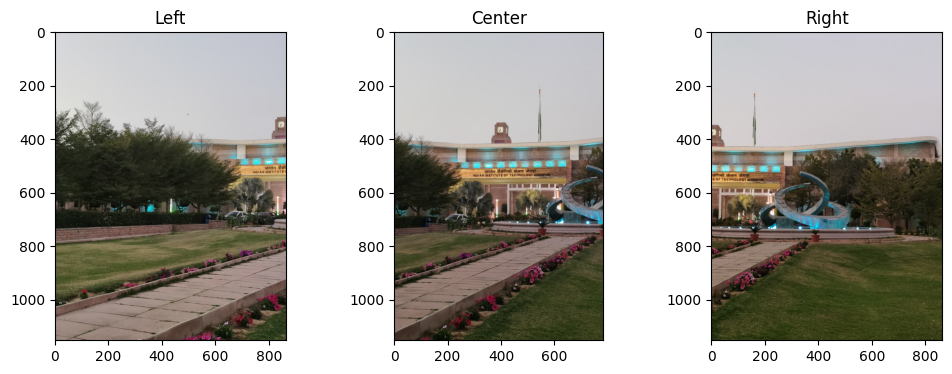

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

imgL = read_image("left.jpg")
imgC = read_image("center.jpg")
imgR = read_image("right.jpg")

plt.figure(figsize=(12,4))
plt.subplot(131); plt.imshow(imgL); plt.title("Left")
plt.subplot(132); plt.imshow(imgC); plt.title("Center")
plt.subplot(133); plt.imshow(imgR); plt.title("Right")
plt.show()


**SIFT Feature Extraction**

In [2]:
def extract_sift(img):
    sift = cv2.SIFT_create()
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kp, des = sift.detectAndCompute(gray, None)
    return kp, des

kpL, desL = extract_sift(imgL)
kpC, desC = extract_sift(imgC)
kpR, desR = extract_sift(imgR)

**Feature Matching**

In [3]:
def match_features(desA, desB, ratio=0.75):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desA, desB, k=2)
    good = []
    for m, n in matches:
        if m.distance < ratio * n.distance:
            good.append(m)
    return good

matches_LC = match_features(desL, desC)
matches_RC = match_features(desR, desC)

**Homography via DLT**

In [4]:
def homography_dlt(src_pts, dst_pts):
    A = []
    for (x, y), (xp, yp) in zip(src_pts, dst_pts):
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])
    A = np.array(A)

    _, _, V = np.linalg.svd(A)
    H = V[-1].reshape(3,3)
    return H / H[2,2]


**RANSAC Homography**

In [5]:
def ransac_homography(kpA, kpB, matches, iters=1200, thresh=4):
    best_H = None
    best_inliers = 0

    for _ in range(iters):
        sample = np.random.choice(matches, 4, replace=False)
        ptsA = np.float32([kpA[m.queryIdx].pt for m in sample])
        ptsB = np.float32([kpB[m.trainIdx].pt for m in sample])

        H = homography_dlt(ptsA, ptsB)
        inliers = 0

        for m in matches:
            x, y = kpA[m.queryIdx].pt
            p = H @ np.array([x, y, 1.0])
            p /= p[2]

            x2, y2 = kpB[m.trainIdx].pt
            if np.linalg.norm(p[:2] - [x2, y2]) < thresh:
                inliers += 1

        if inliers > best_inliers:
            best_inliers = inliers
            best_H = H

    return best_H

H_LC = ransac_homography(kpL, kpC, matches_LC)
H_RC = ransac_homography(kpR, kpC, matches_RC)


**CANVAS SETUP**

In [6]:
hC, wC = imgC.shape[:2]

canvas_h = hC
canvas_w = wC * 3


offset_x = wC

T = np.array([
    [1, 0, offset_x],
    [0, 1, 0],
    [0, 0, 1]
])

H_LC = T @ H_LC
H_C  = T
H_RC = T @ H_RC


**Manual Image Warping**

In [7]:
def _warpimg(img, H, out_shape):
    h, w = out_shape
    _warp_ = np.zeros((h, w, 3), dtype=np.uint8)
    Hinv = np.linalg.inv(H)
    for y in range(h):
        for x in range(w):
            p = Hinv @ np.array([x, y, 1])
            p /= p[2]
            xf, yf = p[0], p[1]
            xi, yi = int(xf), int(yf)

            if 0 <= xi < img.shape[1]-1 and 0 <= yi < img.shape[0]-1:
                dx = xf - xi
                dy = yf - yi
                _warp_[y, x] = (
                    (1-dx)*(1-dy)*img[yi, xi] +
                    dx*(1-dy)*img[yi, xi+1] +
                    (1-dx)*dy*img[yi+1, xi] +
                    dx*dy*img[yi+1, xi+1]
                )
    return _warp_


**Stitch Naive Panorama (Without Blending)**

In [8]:
warpL_n = _warpimg(imgL, H_LC, (canvas_h, canvas_w))
warpC_n = _warpimg(imgC, H_C,  (canvas_h, canvas_w))
warpR_n = _warpimg(imgR, H_RC, (canvas_h, canvas_w))

naive_pano = warpC_n.copy()

maskL = np.any(warpL_n != 0, axis=2)
maskR = np.any(warpR_n != 0, axis=2)

naive_pano[maskL] = warpL_n[maskL]
naive_pano[maskR] = warpR_n[maskR]


**Exposure Compensation**

In [9]:
def align_exposure(ref, img):
    mask_ref = np.any(ref != 0, axis=2)
    mask_img = np.any(img != 0, axis=2)
    overlap = mask_ref & mask_img

    if not np.any(overlap):
        return img

    ref_gray = 0.299*ref[...,0] + 0.587*ref[...,1] + 0.114*ref[...,2]
    img_gray = 0.299*img[...,0] + 0.587*img[...,1] + 0.114*img[...,2]

    gain = np.median(ref_gray[overlap]) / (np.median(img_gray[overlap]) + 1e-6)
    corrected = img.astype(np.float32) * gain
    return np.clip(corrected, 0, 255).astype(np.uint8)


**Seamless Blending**

In [10]:
def weight_field(mask):
    h, w = mask.shape
    weight = np.zeros((h, w), dtype=np.float32)
    ys, xs = np.where(mask)
    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()

    for y in range(h):
        for x in range(w):
            if mask[y, x]:
                weight[y, x] = min(x-min_x, max_x-x, y-min_y, max_y-y)

    return weight / (weight.max() + 1e-6)


def blend(img1, img2):
    m1 = np.any(img1 != 0, axis=2)
    m2 = np.any(img2 != 0, axis=2)

    w1 = weight_field(m1)[...,None]
    w2 = weight_field(m2)[...,None]

    out = np.zeros_like(img1, dtype=np.float32)
    only1 = m1 & ~m2
    only2 = m2 & ~m1
    both  = m1 & m2

    out[only1] = img1[only1]
    out[only2] = img2[only2]
    den = w1 + w2 + 1e-6
    out[both] = (img1[both]*w1[both] + img2[both]*w2[both]) / den[both]

    return out.astype(np.uint8)


**Stitch Final Panorama (Blended)**

In [11]:
warpL = align_exposure(warpC_n, warpL_n)
warpR = align_exposure(warpC_n, warpR_n)

final_panorama = blend(warpC_n, warpL)
final_panorama = blend(final_panorama, warpR)


**Naive Panorama (Direct Stitched)**

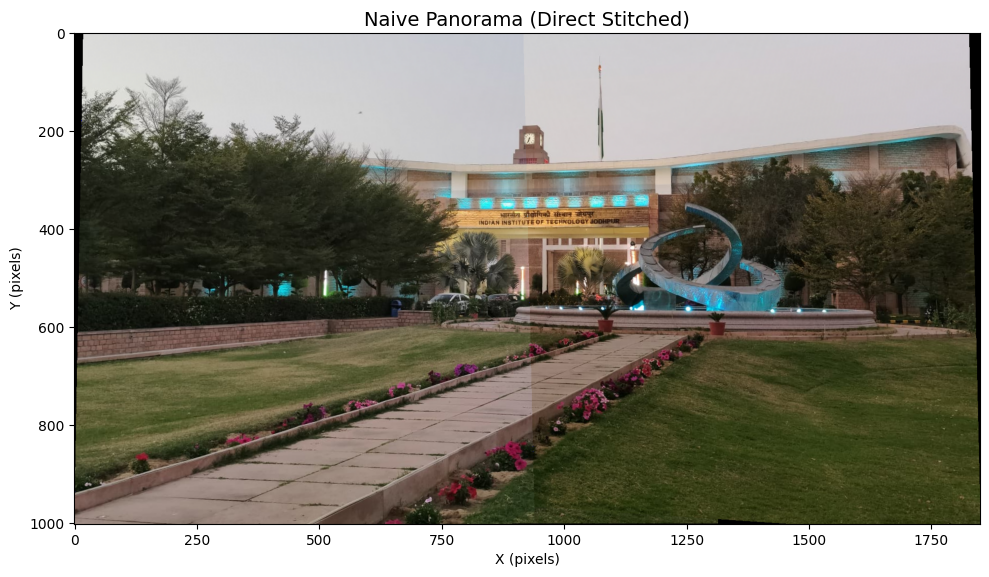

In [12]:
naive_tmp = naive_pano[150:, :]

g_naive = np.mean(naive_tmp, axis=2)
valid_cols = np.where(np.any(g_naive > 5, axis=0))[0]
c_start, c_end = valid_cols[0], valid_cols[-1]
naive_crop = naive_tmp[:, c_start:c_end]

plt.figure(figsize=(10, 6))
plt.imshow(naive_crop)
plt.title("Naive Panorama (Direct Stitched)", fontsize=14)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.tight_layout()
plt.show()


**Final Panorama (Blended)**

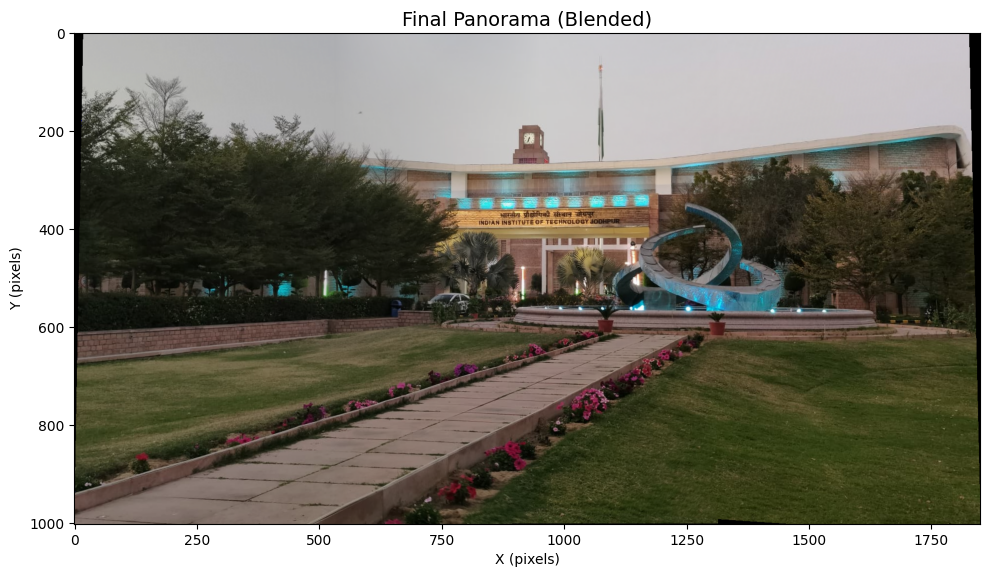

In [13]:
final_tmp = final_panorama[150:, :]

g_final = np.mean(final_tmp, axis=2)
valid_cols = np.where(np.any(g_final > 5, axis=0))[0]
c_start, c_end = valid_cols[0], valid_cols[-1]
final_crop = final_tmp[:, c_start:c_end]


plt.figure(figsize=(10, 6))
plt.imshow(final_crop)
plt.title("Final Panorama (Blended)", fontsize=14)
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.tight_layout()
plt.show()